In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Weight Decay

Now that we have characterized the problem of overfitting,
we can introduce our first *regularization* technique.
Recall that we can always mitigate overfitting
by collecting more training data.
However, that can be costly, time consuming,
or entirely out of our control,
making it impossible in the short run.
For now, we can assume that we already have
as much high-quality data as our resources permit
and focus the tools at our disposal
when the dataset is taken as a given.

Recall that in our polynomial regression example
(that section)
we could limit our model's capacity
by tweaking the degree
of the fitted polynomial.
Indeed, limiting the number of features
is a popular technique for mitigating overfitting.
However, simply tossing aside features
can be too blunt an instrument.
Sticking with the polynomial regression
example, consider what might happen
with high-dimensional input.
The natural extensions of polynomials
to multivariate data are called *monomials*,
which are simply products of powers of variables.
The degree of a monomial is the sum of the powers.
For example, $x_1^2 x_2$, and $x_3 x_5^2$
are both monomials of degree 3.

Note that the number of terms with degree $d$
blows up rapidly as $d$ grows larger.
Given $k$ variables, the number of monomials
of degree $d$ is $\binom{k-1+d}{k-1}$.
Even small changes in degree, say from $2$ to $3$,
dramatically increase the complexity of our model.
Thus we often need a more fine-grained tool
for adjusting function complexity.

In [1]:
%matplotlib inline
from d2l import torch as d2l
import torch
from torch import nn

## Norms and Weight Decay

Rather than directly manipulating the number of parameters,
*weight decay* [@Hanson.Pratt.1988; @Krogh.Hertz.1992] operates by
restricting the values 
that the parameters can take.
Outside of deep learning circles the technique is better known as
$\ell_2$ *regularization* (the two coincide when optimizing by minibatch
SGD, a point we return to below), and it might be the most widely used
technique for regularizing parametric machine learning models.
The technique is motivated by the basic intuition
that among all functions $f$,
the function $f = 0$
(assigning the value $0$ to all inputs)
is in some sense the *simplest*,
and that we can measure the complexity
of a function by the distance of its parameters from zero.
But how precisely should we measure
the distance between a function and zero?
There is no single right answer.
In fact, entire branches of mathematics,
including parts of functional analysis
and the theory of Banach spaces,
are devoted to addressing such issues.

One simple interpretation might be
to measure the complexity of a linear function
$f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x}$
by some norm of its weight vector, e.g., $\| \mathbf{w} \|^2$.
Recall that we introduced the $\ell_2$ norm and $\ell_1$ norm,
which are special cases of the more general $\ell_p$ norm,
in that section.
The most common method for ensuring a small weight vector
is to add its norm as a penalty term
to the problem of minimizing the loss.
Thus we replace our original objective,
*minimizing the prediction loss on the training labels*,
with new objective,
*minimizing the sum of the prediction loss and the penalty term*.
Now, if our weight vector grows too large,
our learning algorithm might focus
on minimizing the weight norm $\| \mathbf{w} \|^2$
rather than minimizing the training error.
That is exactly what we want.
To illustrate things in code,
we revive our previous example
from that section for linear regression.
There, our loss was given by

$$L(\mathbf{w}, b) = \frac{1}{n}\sum_{i=1}^n \frac{1}{2}\left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right)^2.$$

Recall that $\mathbf{x}^{(i)}$ are the features,
$y^{(i)}$ is the label for any data example $i$, and $(\mathbf{w}, b)$
are the weight and bias parameters, respectively.
To penalize the size of the weight vector,
we must somehow add $\| \mathbf{w} \|^2$ to the loss function,
but how should the model trade off the
standard loss for this new additive penalty?
In practice, we characterize this trade-off
via the *regularization constant* $\lambda$,
a nonnegative hyperparameter
that we fit using validation data:

$$L(\mathbf{w}, b) + \frac{\lambda}{2} \|\mathbf{w}\|^2.$$


For $\lambda = 0$, we recover our original loss function.
For $\lambda > 0$, we restrict the size of $\| \mathbf{w} \|$.
We divide by $2$ by convention:
when we take the derivative of a quadratic function,
the $2$ and $1/2$ cancel out, ensuring that the expression
for the update looks nice and simple.
The astute reader might wonder why we work with the squared
norm and not the standard norm (i.e., the Euclidean distance).
We do this for computational convenience.
By squaring the $\ell_2$ norm, we remove the square root,
leaving the sum of squares of
each component of the weight vector.
This makes the derivative of the penalty easy to compute: 
the sum of derivatives equals the derivative of the sum.


Moreover, you might ask why we work with the $\ell_2$ norm
in the first place and not, say, the $\ell_1$ norm.
In fact, other choices are valid and
popular throughout statistics.
While $\ell_2$-regularized linear models constitute
the classic *ridge regression* algorithm [@Hoerl.Kennard.1970],
$\ell_1$-regularized linear regression
is a similarly fundamental method in statistics, 
popularly known as *lasso regression* [@Tibshirani.1996].
One reason to work with the $\ell_2$ norm
is that it places an outsize penalty
on large components of the weight vector.
This biases our learning algorithm
towards models that distribute weight evenly
across a larger number of features.
In practice, this might make them more robust
to measurement error in a single variable.
By contrast, $\ell_1$ penalties lead to models
that concentrate weights on a small set of features
by clearing the other weights to zero.
This gives us an effective method for *feature selection*,
which may be desirable for other reasons.
For example, if our model only relies on a few features,
then we may not need to collect, store, or transmit data
for the other (dropped) features. 

These two penalties are easiest to compare geometrically. For a corresponding
budget $t$, minimizing $L(\mathbf{w}) + \frac{\lambda}{2}\|\mathbf{w}\|^2$ is
equivalent to minimizing $L(\mathbf{w})$ subject to $\|\mathbf{w}\| \le t$, and
the regularized solution is the first point at which a loss contour meets the
constraint region (the figure). A smooth $\ell_2$ boundary
usually shrinks coordinates without making them exactly zero. The corners and
faces of the $\ell_1$ ball make exact zeros much more common, although sparsity
is not guaranteed for every loss and dataset. This geometry explains why lasso
can perform feature selection while ridge usually does not.
We assert the penalty$\,\Leftrightarrow\,$constraint equivalence here;
that section derives it via Lagrange
duality ($\lambda$ is exactly the multiplier attached to the constraint
$\|\mathbf{w}\| \le t$) and computes the $\lambda \leftrightarrow t$
correspondence numerically on ridge regression.

![Weight decay as a constraint. The elliptical contours of the training loss $L(\mathbf{w})$, centred on the unconstrained optimum $\hat{\mathbf{w}}$, grow until they meet the constraint region at the regularized solution $\mathbf{w}^\star$. Left: the $\ell_2$ ball is met *tangentially*, shrinking both coordinates. Right: the $\ell_1$ diamond is met at a *corner*, forcing $w_2$ to exactly zero: the sparsity that distinguishes lasso from ridge.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-linreg-ridge-geometry.svg)

Using the same notation in the equation,
minibatch stochastic gradient descent updates
for $\ell_2$-regularized regression as follows:

$$\begin{aligned}
\mathbf{w} & \leftarrow \left(1- \eta\lambda \right) \mathbf{w} - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \mathbf{x}^{(i)} \left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right).
\end{aligned}$$

As before, we update $\mathbf{w}$ based on the amount
by which our estimate differs from the observation.
However, we also shrink the size of $\mathbf{w}$ towards zero.
That is why the method is sometimes called "weight decay":
given the penalty term alone,
our optimization algorithm *decays*
the weight at each step of training.
In contrast to feature selection,
weight decay offers us a mechanism for continuously adjusting the complexity of a function.
Smaller values of $\lambda$ correspond
to less constrained $\mathbf{w}$,
whereas larger values of $\lambda$
constrain $\mathbf{w}$ more considerably.
Whether we include a corresponding bias penalty $b^2$ 
can vary across implementations, 
and may vary across layers of a neural network.
Often, we do not regularize the bias term.
For plain minibatch stochastic gradient descent, adding
$\frac{\lambda}{2}\|\mathbf{w}\|^2$ to the loss and applying the shrink-and-update
rule above are one and the same. This equivalence is special to SGD: for adaptive
optimizers such as Adam, a penalty placed inside the loss is rescaled by the
optimizer's per-coordinate second-moment estimates and no longer acts as uniform
weight shrinkage. *Decoupling* the decay from the loss gradient (shrinking every
weight by a fixed fraction at each step) restores the intended behavior; this is
the decoupled-weight-decay variant AdamW, introduced by
@Loshchilov.Hutter.2019 and now a default optimizer for large models.
The mechanism (including the per-coordinate shrinkage formula and a code
demonstration racing the coupled and decoupled variants) is worked out in
that section, and we take up optimizers in
detail in that section.

Finally, weight decay also has a probabilistic reading. Recall from
that section that minimizing the squared
loss is maximum likelihood estimation under Gaussian observation noise. Now place
an isotropic Gaussian *prior* $\mathbf{w} \sim \mathcal{N}(\mathbf{0}, \tau^2\mathbf{I})$
on the weights and ask instead for the weights that maximize the *posterior*
$p(\mathbf{w} \mid \mathbf{X}, \mathbf{y}) \propto p(\mathbf{y} \mid \mathbf{X}, \mathbf{w})\, p(\mathbf{w})$, the
*maximum a posteriori* (MAP) estimate. Taking negative logarithms, the prior
contributes

$$-\log p(\mathbf{w}) = \frac{1}{2\tau^2} \|\mathbf{w}\|^2 + \textrm{const},$$

so the MAP objective is the Gaussian negative log-likelihood of
that section plus a quadratic penalty:

$$-\log p(\mathbf{w} \mid \mathbf{X}, \mathbf{y}) = \frac{1}{2\sigma^2} \sum_{i=1}^n \left(y^{(i)} - \mathbf{w}^\top \mathbf{x}^{(i)} - b\right)^2 + \frac{1}{2\tau^2} \|\mathbf{w}\|^2 + \textrm{const}.$$

In short, *MAP estimation is maximum likelihood plus a prior*, and the objective
above is exactly of our weight-decay form. The regularization constant $\lambda$
is thereby *proportional to* the prior precision $1/\tau^2$: a tighter prior
(smaller $\tau$) means stronger shrinkage. The exact constant of proportionality
involves the noise variance $\sigma^2$ and the sample size $n$, because the loss
$L$ above is an *average* while the log-posterior is a *sum*; exercise 6 asks you
to make the correspondence precise. the figure illustrates this:
the prior's quadratic bowl pulls the maximum-likelihood estimate back
toward the origin. This recovers the classical *ridge regression* estimator.

![The MAP reading of weight decay is a tug-of-war between data and prior. The negative log-likelihood (blue) is minimized at the MLE; adding the Gaussian prior's quadratic bowl (orange, dashed) yields the MAP objective (green), whose minimum is pulled from the MLE toward the prior mean, which for weight decay is the origin. A tighter prior (smaller $\tau$) pulls harder.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-prob-map-prior.svg)

## High-Dimensional Linear Regression

We can illustrate the benefits of weight decay 
through a simple synthetic example.

First, we generate some data as before:

$$y = 0.05 + \sum_{i = 1}^d 0.01 x_i + \epsilon \textrm{ where }
\epsilon \sim \mathcal{N}(0, 0.01^2).$$

In this synthetic dataset, our label is given 
by an underlying linear function of our inputs,
corrupted by Gaussian noise 
with zero mean and standard deviation 0.01.
For illustrative purposes, 
we can make the effects of overfitting pronounced,
by increasing the dimensionality of our problem to $d = 200$
and working with a small training set with only 20 examples.

In [2]:
class Data(d2l.DataModule):
    def __init__(self, num_train, num_val, num_inputs, batch_size):
        self.save_hyperparameters()                
        n = num_train + num_val 
        self.X = d2l.randn(n, num_inputs)
        noise = d2l.randn(n, 1) * 0.01
        w, b = d2l.ones((num_inputs, 1)) * 0.01, 0.05
        self.y = d2l.matmul(self.X, w) + b + noise

    def get_dataloader(self, train):
        i = slice(0, self.num_train) if train else slice(self.num_train, None)
        return self.get_tensorloader([self.X, self.y], train, i)

## Implementation from Scratch

Now, let's try implementing weight decay from scratch.
Since minibatch stochastic gradient descent
is our optimizer,
we just need to add the squared $\ell_2$ penalty
to the original loss function.

### Defining $\ell_2$ Norm Penalty

Perhaps the most convenient way of implementing this penalty
is to square all terms in place and sum them.

In [3]:
def l2_penalty(w):
    return d2l.reduce_sum(w**2) / 2

### Defining the Model

In the final model,
the linear regression and the squared loss have not changed since that section,
so we will just define a subclass of `d2l.LinearRegressionScratch`. The only change here is that our loss now includes the penalty term.

In [4]:
class WeightDecayScratch(d2l.LinearRegressionScratch):
    def __init__(self, num_inputs, lambd, lr, sigma=0.01):
        super().__init__(num_inputs, lr, sigma)
        self.save_hyperparameters()
        
    def loss(self, y_hat, y):
        return (super().loss(y_hat, y) +
                self.lambd * l2_penalty(self.w))

The following code fits our model on the training set with 20 examples and evaluates it on the validation set with 100 examples.

In [5]:
data = Data(num_train=20, num_val=100, num_inputs=200, batch_size=5)
trainer = d2l.Trainer(max_epochs=30)

def train_scratch(lambd):    
    model = WeightDecayScratch(num_inputs=200, lambd=lambd, lr=0.01)
    model.board.yscale='log'
    trainer.fit(model, data)
    print('L2 norm of w:', float(l2_penalty(model.w).detach()))

### Training without Regularization

We now run this code with `lambd = 0`,
disabling weight decay.
Note that we overfit badly,
decreasing the training error but not the
validation error, a textbook case of overfitting.

L2 norm of w: 0.010326704010367393


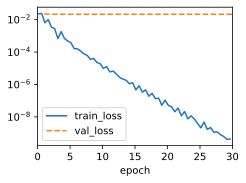

In [6]:
train_scratch(0)

### Using Weight Decay

Below, we run with substantial weight decay.
Note that the training error increases
but the validation error decreases.
This is precisely the effect
we expect from regularization.

L2 norm of w: 0.000597748497966677


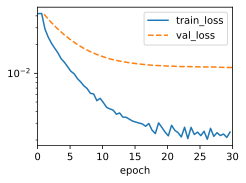

In [7]:
train_scratch(3)

### Why Shrinkage Helps: The Spectral View

The geometry of the figure says that the penalty pulls
$\hat{\mathbf{w}}$ toward the origin, but not *which parts* of
$\hat{\mathbf{w}}$ are pulled hardest. For linear regression we can say
exactly. Adding the penalty keeps the problem quadratic, so it retains a
closed-form solution (dropping the unpenalized intercept, which centering
absorbs): minimizing
$\frac{1}{2}\|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2 + \frac{\tilde{\lambda}}{2}\|\mathbf{w}\|^2$
gives

$$\mathbf{w}^*_{\tilde{\lambda}} = (\mathbf{X}^\top \mathbf{X} + \tilde{\lambda} \mathbf{I})^{-1} \mathbf{X}^\top \mathbf{y},$$

which is well defined for every $\tilde{\lambda} > 0$ even when
$\mathbf{X}^\top \mathbf{X}$ is singular; this is the estimator promised in
exercise 4.5 of that section. (Because the loss $L$ of this
section *averages* over the $n$ examples while the objective above sums, the two
conventions are related by $\tilde{\lambda} = n\lambda$.)

To see what this estimator does, substitute the singular value decomposition
$\mathbf{X} = \mathbf{U}\mathbf{D}\mathbf{V}^\top$
(that section). A short calculation shows that the ridge
prediction is

$$\mathbf{X}\mathbf{w}^*_{\tilde{\lambda}} = \sum_j \mathbf{u}_j\, \frac{d_j^2}{d_j^2 + \tilde{\lambda}}\, \mathbf{u}_j^\top \mathbf{y},$$

whereas ordinary least squares gives $\sum_j \mathbf{u}_j \mathbf{u}_j^\top \mathbf{y}$,
the orthogonal projection from that section. Ridge therefore
*shrinks* the response along the $j$-th principal direction of the data by the
factor $d_j^2 / (d_j^2 + \tilde{\lambda})$. Directions with large singular value
$d_j$ (strongly represented in the data) pass through almost untouched, while
directions with small $d_j$, where a little noise in $\mathbf{y}$ produces a wild
swing in $\mathbf{w}$, are suppressed hardest. This is the quantitative reason
shrinkage tames overfitting: it damps precisely the directions that the data
constrains least, the ones a noise-chasing fit exploits. Summing the
per-direction factors yields the *effective degrees of freedom*

$$\textrm{df}(\tilde{\lambda}) = \sum_j \frac{d_j^2}{d_j^2 + \tilde{\lambda}},$$

which slides continuously from $\textrm{rank}(\mathbf{X})$ at
$\tilde{\lambda} = 0$ toward $0$ as $\tilde{\lambda} \to \infty$, the
"continuous complexity dial" from the start of this section, made literal.
Let's compute these quantities on the very dataset we just trained on.

In [8]:
d = torch.linalg.svdvals(data.X[:data.num_train])
for lam in (0, 3, 30):
    shrink = d**2 / (d**2 + data.num_train * lam)
    print(f'lambda={lam:2d}  df={float(d2l.reduce_sum(shrink)):5.1f}  '
          f'strongest {float(shrink[0]):.2f}  weakest {float(shrink[-1]):.2f}')

lambda= 0  df= 20.0  strongest 1.00  weakest 1.00
lambda= 3  df= 15.0  strongest 0.84  weakest 0.62
lambda=30  df=  4.8  strongest 0.34  weakest 0.14


Two things stand out. First, 20 training examples constrain at most 20
directions of the 200-dimensional weight space:
$\textrm{rank}(\mathbf{X}) = 20$, so $\textrm{df}(0) = 20$. Gradient descent
from zero remains in the row space of $\mathbf{X}$ and does not invent
components in the 180-dimensional nullspace. Overfitting instead comes from
matching noise along the data-supported directions, especially those with
small singular values. Second, at the $\lambda = 3$ that lowered the
validation loss above, every shrinkage factor drops below one, the weakest
directions are damped most, and $\textrm{df}(\lambda)$ falls well below 20: the
regularized model behaves like one with far fewer parameters than its nominal
200, which is exactly the continuous capacity control weight decay provides
(that section).

## Concise Implementation

Because weight decay is ubiquitous
in neural network optimization,
deep learning frameworks make it especially convenient,
integrating weight decay into the optimization algorithm itself
for easy use in combination with any loss function.
Moreover, this integration serves a computational benefit,
allowing implementation tricks to add weight decay to the algorithm,
without any additional computational overhead.
Since the weight decay portion of the update
depends only on the current value of each parameter,
the optimizer must touch each parameter once anyway.

Below, we specify
the weight decay hyperparameter directly
through `weight_decay` when instantiating our optimizer.
By default, PyTorch decays both
weights and biases simultaneously, but
we can configure the optimizer to handle different parameters
according to different policies.
Here, we only set `weight_decay` for
the weights (the `net.weight` parameters), hence the 
bias (the `net.bias` parameter) will not decay.

In [9]:
class WeightDecay(d2l.LinearRegression):
    def __init__(self, wd, lr):
        super().__init__(lr)
        self.save_hyperparameters()
        self.wd = wd

    def configure_optimizers(self):
        return torch.optim.SGD([
            {'params': self.net.weight, 'weight_decay': self.wd},
            {'params': self.net.bias}], lr=self.lr)

This version runs faster and is easier to implement than the from-scratch code,
benefits that grow more pronounced on larger problems and as this work becomes
routine. One subtlety: a framework's `weight_decay` adds the
term $\lambda\mathbf{w}$ to the *gradient*, whereas our from-scratch penalty added
$\frac{\lambda}{2}\|\mathbf{w}\|^2$ to the *loss*. When the loss omits the
$\frac{1}{2}$ factor (as PyTorch's `nn.MSELoss` does), the two correspond to
slightly different effective values of $\lambda$, so the converged
$\|\mathbf{w}\|^2$ need not match the from-scratch value exactly, even though the
regularizing effect is the same.

L2 norm of w: 0.0010012428974732757


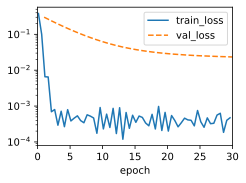

In [10]:
model = WeightDecay(wd=3, lr=0.01)
model.board.yscale='log'
trainer.fit(model, data)

print('L2 norm of w:', float(l2_penalty(model.get_w_b()[0]).detach()))

So far we have measured complexity through the norm of a *linear* function's
weights. The same principle extends to the nonlinear functions a deep network
computes: in practice we simply apply weight decay to the parameters of every
layer, a simple, effective heuristic we adopt throughout the book.

## Summary

Regularization is a common method for dealing with overfitting. Classical regularization techniques add a penalty term to the loss function (when training) to reduce the complexity of the learned model.
One particular choice for keeping the model simple is using an $\ell_2$ penalty. This leads to weight decay in the update steps of the minibatch stochastic gradient descent algorithm.
In practice, the weight decay functionality is provided in optimizers from deep learning frameworks.
Different sets of parameters can have different update behaviors within the same training loop.


## Exercises

1. Experiment with the value of $\lambda$ in the estimation problem in this section. Plot training and validation loss as a function of $\lambda$. What do you observe? Hint: expect a U-shaped validation curve, with $\lambda$ (equivalently, $\textrm{df}(\lambda)$) playing the role of the complexity dial (compare the figure).
1. Use a validation set to find the optimal value of $\lambda$. Is it really the optimal value? Does this matter?
1. What would the update equations look like if instead of $\|\mathbf{w}\|^2$ we used $\sum_i |w_i|$ as our penalty of choice ($\ell_1$ regularization)?
1. We know that $\|\mathbf{w}\|^2 = \mathbf{w}^\top \mathbf{w}$. Can you find a similar equation for matrices (see the Frobenius norm in that section)?
1. Review the relationship between training error and generalization error. In addition to weight decay, increased training, and the use of a model of suitable complexity, what other ways might help us deal with overfitting?
1. Make the MAP correspondence of the figure precise. Starting from the posterior $P(\mathbf{w} \mid \mathbf{X}, \mathbf{y}) \propto P(\mathbf{y} \mid \mathbf{X}, \mathbf{w}) P(\mathbf{w})$ with noise variance $\sigma^2$ and prior $\mathbf{w} \sim \mathcal{N}(\mathbf{0}, \tau^2 \mathbf{I})$, show that minimizing the negative log-posterior is equivalent to minimizing the *averaged* loss $L(\mathbf{w}, b) + \frac{\lambda}{2}\|\mathbf{w}\|^2$ of this section with $\lambda = \sigma^2 / (n \tau^2)$. Which prior standard deviation $\tau$ corresponds to the $\lambda = 3$ used in the experiments above?

[Discussions](https://d2l.discourse.group/t/99)